# 如何判定模型好坏？
不能单看某一基准，而是要建立 **基础能力 - 专项能力 - 安全合规 - 工程性能 - 业务价值** 的五层评估体系，同时结合 **自动评估、人工评估和真实场景 A/B 测试** 三种测试方法

## 分层详细阐述

### 第一层：基础通用能力评估
这是大模型基本功，决定模型的上限，通过**标准化基准测试**完成
- 核心能力维度及对应权威基准
    - **知识储备与理解**： 
        - C-Eval（中文综合知识评测，覆盖多学科领域知识）。
    - **逻辑推理与数学**： 
        - Spec Bench（推测解码基准，多类别推理任务）
        - Math 500（数学推理基准）。
    - **对话与语言生成**：
        - AIAK bench（单/多轮混合对话，业务流量采样）
        - MT Bench（多轮对话基准）
        - Custom Bench（通用自定义混合对话。ds_all_2000）
    - **代码能力**：
        - LiveCodeBench V6（代码生成与理解。LCB v6 子集）
        - M25 Code Plan Zijian Eval（代码规划子健评测集）
        - Codeplan GLM5 2k（GLM5 coding plan 评测。2K 随机样本）
        - Codeplan GLM5 500（GLM5 coding plan shuffle 子集）
        - Codeplan DSV32 500（Deepseek-V3.2 coding plan 子集）
        - Codeplan M25 2k 0324（M25 coding plan 2K 评测集）
        - DSV32 0422（Deepseek-V3.2 按 prompt 长度分层评测。如 xx_gt8k / xx_l8k）
        - DSV32 0422 Think（DSV32 Thinking 模式按长度分层评测 | 2000 | generate）
    - **Agent 能力**：
        - GLM5 Agentic Baige 1K（GLM5 智能体百舸场景评测，含 tool 调用）
    - **千帆平台业务场景**：
        - Qianfan SFT Bench（千帆 SFT 训练分布采样 2K）
        - Qianfan Xiaotong 1K Origin（千帆小桶业务流量 2K 评测）
        ...
    - **真实流量回访**：
        - M25 Reflow 0402 高低峰（2026-04-02 高低流量窗口回放）
        ...
    - **推理加速性能**：
        - Speed Bench Qualitative（NVIDIA SPEED-Bench 质量子集）
        - Speed Bench Throughput（SPEED-Bench 32k 长度吞吐测试）
        ...
    - **专项验证**：
        - AIAK Test 200（AIAK 200 提轻量测试集）

- Tips
    - 基准测试局限性：刷分现象，即大模型可能记住了测试集答案。
    - 补充：会使用闭卷测试（不给上下文）和开卷测试（给参考文档），区分模型的'记忆能力'和'应用能力'

### 第二层：专项任务能力评估（业务适配关键）
通用能力强不等于业务表现好，这是区分'能用'和'好用'的核心。必须**针对具体业务场景设计定制化评估指标**。
- 常见业务场景及核心指标
    - 客服场景：问题解决率、平均对话轮次、转人工率。
    - 代码助手场景：代码通过率、BUG 率、代码可读性、上下文理解能力。
    - 内容创作场景：相关性、原创性、风格一致性（尤为关键）、事实准确性。
    - RAG 场景：检索准确率、召回率、答案引用率、幻觉率。
- Tips:
    - 举例说明：比如企业内部知识库助手时，除了看答案的正确率，还会重点评估答案是否能精准定位到知识库汇总的具体章节，以及党知识库没有相关信息时，模型是否能如实告知而非编造。
    - 强调：专项评估要覆盖**边界 case**。比如超长输入、歧义问题、口语化表达、专业术语混用等

### 第三层：安全与合规评估（红线底线）
这是大模型能否上线的前提，也是现在企业最重视的部分。
- 核心评估维度：
    - 有害内容生成：暴力、色情、政治敏感、违法违规内容
    - 偏见与歧视：性别、种族、地域、职业等偏见
    - 隐私保护：是否泄露用户隐私、训练数据中的敏感信息
    - 幻觉问题：编造事实、虚假引用、错误结论
    - 合规性：是否符合行业规范
- 常用方法：
    - 安全基准测试：HarmBench
    - 红队测试：由专业人员设计恶意 prompt 进行渗透测试
    - 事实核查：将模型回答与权威知识库比对
- Tips:
    - 提到：安全评估是一个持续的过程，上线后需要建立实时监控机制，做到主动发现与修复安全漏洞的工作链
    - 区分：幻觉分为有害幻觉和无害幻觉，需要严格避免有害幻觉的产生。

### 第四层：工程性能评估（落地可行性）
大模型最终要服务用户，性能直接影响用户体验和成本
- 核心指标
    - 推理速度： 首 token 延迟（TTFT）
    - 吞吐量：单位时间内 token 处理能力
    - 资源占用：内存、显存、磁盘 I/O、网络带宽等
    - 并发能力：支持并发请求数（RPS）
    - 成本：部署成本、每千 tokens 推理成本

- Tips:
    - 结合量化技术：评估不同量化精度（FP16、INT8、INT4）对模型效果和性能的影响，在保证效果的前提下尽可能降低成本
    - 鲁棒性考验：在高并发、超长输入等极端场景下的稳定性

### 第五层：业务价值评估（最终标准）
所有技术评估最终都要服务于业务价值，这是判断模型是否成功的唯一标准。
- 核心指标：
    - 用户侧：用户满意度、留存率、使用时长
    - 业务侧：转化率、成本节约、营收
    - 运营侧：人工干预率、客服工作量、问题解决时间
- Tips:
    - 举例：上线数字员工后，工作群即使不会 coding 的 PM 也能快速通过白话文实现 kv-cache 任务自助查询管理。
    - 强调：业务价值评估不能只看短期数据，还要考虑长期影响，比如用户对功能的认知程度、同事的使用体验等。

## 评估方法的结合使用
没有一种评估方法是完美的，我们需要将三种方法结合使用

- 自动评估：快速、可重复和基准验证，对比
- 人工评估：准确、全面，补充自动评估无法衡量的主观质量（如流畅度、逻辑性和创造性）
- A/B 测试：最真实、最有说服力，上线前的最终测试验证，直接对比新旧模型的表现。

## 评估中常见的挑战及应对

- 挑战 1：幻觉问题难以量化
应对： 建立自动事实核查 + 人工抽样审核机制，引入答案置信度指标，让模型在不确定时主动说明。

- 挑战 2：主观质量评估一致性差
应对：制定详细的人工评估标准，对评估人员进行培训，采用多人交叉评估。

- 挑战 3：评估基准快速过时
应对：定期更新评估数据集，同时使用“动态基准”（如实时抓取的最新问题）进行测试。

- 挑战 4：多轮对话评估复杂
应对：设计完整的对话流程测试用例，评估模型的上下文记忆能力、对话连贯性和任务完成能力。

- 挑战 5： LCB
**LCB 介绍**
    - 革命性的动态污染防护机制
        - 持续试试更新、时间戳精准过滤（评估时仅使用模型训练截止日期之后发布的问题）、污染检测能力
    - 采用了严格的五层分离架构，使部署和扩展变得极其灵活
        ```
        用户界面层(CLI/配置文件)
            ↓
        模型注册层(LanguageModelStore)
            ↓
        提示工程层(场景专用格式化器)
            ↓
        执行层(Runner工厂)
            ↓
        评估层(沙箱执行+指标计算)
        ```


# Lesson 1: 模型评估基础概念 & 数据集划分

## 学习目标
1. 理解为什么需要模型评估（不是训练越好就越好）
2. 掌握训练集/验证集/测试集的划分方法
3. 理解过拟合与欠拟合
4. 动手实践数据集划分

---

## 核心概念

| 概念 | 说明 |
|------|------|
| **训练集 (Training Set)** | 用来训练模型的数据，模型从中学习规律 |
| **验证集 (Validation Set)** | 用来调参、选模型，不参与训练 |
| **测试集 (Test Set)** | 最终评估模型效果，模拟真实场景，绝不能提前看 |
| **过拟合 (Overfitting)** | 训练集表现好，测试集表现差 —— 模型"背答案"了 |
| **欠拟合 (Underfitting)** | 训练集和测试集都表现差 —— 模型太简单，没学到规律 |

## Part 1: 加载数据并观察

In [28]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# 加载经典的鸢尾花数据集
iris = load_iris()

print(f"数据形状: {iris.data.shape}")  # 150个样本，4个特征
print(f"目标类别: {iris.target_names}")  # 3类花
print(f"特征名称: {iris.feature_names}")

# 转成 DataFrame 方便查看
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("\n--- 前5行数据 ---")
df.head()

数据形状: (150, 4)
目标类别: ['setosa' 'versicolor' 'virginica']
特征名称: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

--- 前5行数据 ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [26]:
# 查看各类别数量分布
print("各类别样本数:")
print(df['species'].value_counts())

print(f"\n总样本数: {len(df)}")
print(f"\n基本统计:")
df.describe() 

各类别样本数:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

总样本数: 150

基本统计:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Part 2: 手动划分 vs sklearn 划分

### 2.1 错误示范：不打乱直接切
如果数据是按类别排序的（iris就是），直接切前80%做训练集，会怎样？

In [29]:
# 错误示范：直接按顺序切分
X, y = iris.data, iris.target

split_idx = int(len(X) * 0.8)  # 前80%训练
X_train_bad = X[:split_idx]
y_train_bad = y[:split_idx]
X_test_bad = X[split_idx:]
y_test_bad = y[split_idx:]

print("=== 错误切分 ===")
print(f"训练集类别分布: {np.bincount(y_train_bad)}")  # 类别2很少！
print(f"测试集类别分布: {np.bincount(y_test_bad)}")    # 几乎全是类别2！
print("\n问题: 训练集几乎没见过类别2的样本，测试集全是类别2 → 必然预测很差")

=== 错误切分 ===
训练集类别分布: [50 50 20]
测试集类别分布: [ 0  0 30]

问题: 训练集几乎没见过类别2的样本，测试集全是类别2 → 必然预测很差


In [47]:
# 正确做法：使用 sklearn 的 train_test_split
from sklearn.model_selection import train_test_split

# stratify=y 保证各类别比例一致（分层抽样）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,     # 20%做测试
    random_state=42,   # 固定随机种子，保证可复现
    stratify=y         # 关键！保持类别比例
)

print("=== 正确切分 (stratify) ===")
print(f"训练集大小: {len(X_train)}, 测试集大小: {len(X_test)}")
print(f"训练集类别分布: {np.bincount(y_train)}")
print(f"测试集类别分布: {np.bincount(y_test)}")
print("\n各类别比例基本一致!")

=== 正确切分 (stratify) ===
训练集大小: 120, 测试集大小: 30
训练集类别分布: [40 40 40]
测试集类别分布: [10 10 10]

各类别比例基本一致!


### 2.2 三种常见划分比例

| 数据量 | 推荐划分 | 说明 |
|--------|----------|------|
| 小数据(<1000) | 70/15/15 或直接用交叉验证 | 数据珍贵，需要充分利用 |
| 中等数据(1000-100000) | 80/10/10 | 常见做法 |
| 大数据(>100000) | 98/1/1 | 测试集1%已经够评估了 |

In [48]:
# 实践：训练集/验证集/测试集 三分
# 先分出测试集，再从剩余中分出验证集

# 第一步: 分出 20% 测试集
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 第二步: 从剩余的80%中再分出 25%作为验证集 (即总数据的20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"训练集: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"验证集: {len(X_val)} ({len(X_val)/len(X)*100:.0f}%)")
print(f"测试集: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"总计:   {len(X_train) + len(X_val) + len(X_test)}")

训练集: 90 (60%)
验证集: 30 (20%)
测试集: 30 (20%)
总计:   150


## Part 3: 过拟合 vs 欠拟合 直观演示

用多项式回归来直观展示什么是过拟合和欠拟合。

/tmp/ipykernel_888103/4212410060.py:43: UserWarning: Glyph 27424 (\N{CJK UNIFIED IDEOGRAPH-6B20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_888103/4212410060.py:43: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_888103/4212410060.py:43: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_888103/4212410060.py:43: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_888103/4212410060.py:43: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_888103/4212410060.py:43: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_888103/4212410060.py:43: UserWarning: Glyph 35797 (\N{CJK UNIFIED I

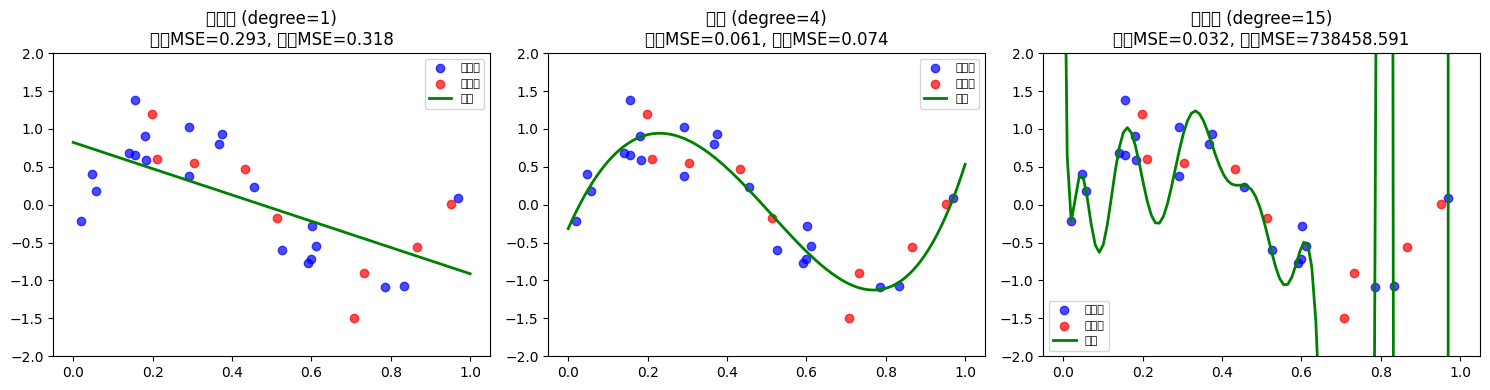

关键观察:
- 欠拟合: 训练误差大，测试误差也大 (模型太简单)
- 合适:   训练误差适中，测试误差也适中 (模型复杂度合适)
- 过拟合: 训练误差很小，但测试误差很大 (模型太复杂，记住了噪声)


In [49]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 生成带噪声的正弦数据
np.random.seed(42)
n_samples = 30
X_demo = np.sort(np.random.uniform(0, 1, n_samples))
y_demo = np.sin(2 * np.pi * X_demo) + np.random.normal(0, 0.3, n_samples)

# 划分训练和测试
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_demo.reshape(-1, 1), y_demo, test_size=0.3, random_state=42
)

# 用不同复杂度的模型拟合
degrees = [1, 4, 15]  # 欠拟合、合适、过拟合
titles = ['欠拟合 (degree=1)', '合适 (degree=4)', '过拟合 (degree=15)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
X_plot = np.linspace(0, 1, 100).reshape(-1, 1)

for ax, degree, title in zip(axes, degrees, titles):
    # 多项式特征 + 线性回归
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train_d)
    X_test_poly = poly.transform(X_test_d)
    X_plot_poly = poly.transform(X_plot)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train_d)
    
    train_mse = mean_squared_error(y_train_d, model.predict(X_train_poly))
    test_mse = mean_squared_error(y_test_d, model.predict(X_test_poly))
    
    ax.scatter(X_train_d, y_train_d, color='blue', label='训练集', alpha=0.7)
    ax.scatter(X_test_d, y_test_d, color='red', label='测试集', alpha=0.7)
    ax.plot(X_plot, model.predict(X_plot_poly), 'g-', linewidth=2, label='模型')
    ax.set_title(f"{title}\n训练MSE={train_mse:.3f}, 测试MSE={test_mse:.3f}")
    ax.legend(fontsize=8)
    ax.set_ylim(-2, 2)

plt.tight_layout()
plt.savefig('01_overfit_underfit.png', dpi=100, bbox_inches='tight')
plt.show()
print("关键观察:")
print("- 欠拟合: 训练误差大，测试误差也大 (模型太简单)")
print("- 合适:   训练误差适中，测试误差也适中 (模型复杂度合适)")
print("- 过拟合: 训练误差很小，但测试误差很大 (模型太复杂，记住了噪声)")

## Part 4: 练习题

### 练习1: 用 wine 数据集做划分
要求:
1. 加载 `sklearn.datasets.load_wine()` 数据集
2. 打印数据形状和类别分布
3. 用 `train_test_split` 按 70/30 划分，使用分层抽样
4. 验证训练集和测试集的类别比例是否一致

In [101]:
# === 你的代码 ===
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# 1. 加载数据
wine = load_wine()

print(f"数据集形状：\n{wine.data.shape}") # (178, 13) | （样本数，类别）
print(f"目标类别：\n {wine.target_names}")
print(f"特征名称：\n{wine.feature_names}")

print(f"目标类别分布：\n{np.bincount(wine.target)}")

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['species'] = df['target'].map(dict(enumerate(wine.target_names)))

df.head()

# 2. 打印数据信息
print(f"===\n各类别样本数：\n{df['species'].value_counts()}\n===")
print(f"总样本数：{len(df)}")
print(f"基本统计：\n{df.describe()}")

# 3. 划分数据集
wine_train, wine_test, target_train, target_test = train_test_split(wine.data, wine.target, test_size=0.3, random_state=9527, stratify=wine.target)
print(f"训练集大小：{len(wine_train)}({len(wine_train)/len(wine.data)*100:.0f}%)，训练集类别分布：{np.bincount(target_train)}")
print(f"测试集大小：{len(wine_test)}({len(wine_test)/len(wine.data)*100:.0f}%)，测试集类别分布：{np.bincount(target_test)}")


# 4. 验证类别比例
print(np.bincount(target_train))
print(np.bincount(target_test))


数据集形状：
(178, 13)
目标类别：
 ['class_0' 'class_1' 'class_2']
特征名称：
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
目标类别分布：
[59 71 48]
===
各类别样本数：
species
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64
===
总样本数：178
基本统计：
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.0000

### 练习2: 思考题
1. 如果你有一个10万条数据的文本分类任务，你会怎么划分？
2. `random_state` 的作用是什么？不设置会怎样？
3. 什么时候必须用 `stratify` 参数？

---
## 小结

| 知识点 | 关键要点 |
|--------|----------|
| 数据集划分 | 一定要随机打乱，分类问题用分层抽样 |
| 测试集 | 绝对不能参与训练和调参，模拟"未来的新数据" |
| 过拟合 | 训练好/测试差，增加数据或降低模型复杂度 |
| 欠拟合 | 训练差/测试差，增加模型复杂度或增加特征 |
| random_state | 固定种子保证可复现 |

**下一课: 分类模型的评估指标 (Accuracy, Precision, Recall, F1, AUC)**